# Trade Behaviour Risk & Anomaly Detection — Multi-Model Benchmarking

Training and benchmarking candidate anomaly detection models: Isolation Forest, XGBoost, and Autoencoders (MLP, GRU, TCN, Transformer).

## Setup & Library Imports

In [1]:
import sys
import os
import json
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve
)

from src.trade_anomaly.data_loader import load_trade_anomaly_data
from src.trade_anomaly.feature_pipeline import (
    compute_causal_features_for_df,
    create_chronological_splits,
    TradeAnomalyPreprocessor,
    CORE_NUMERICAL_FEATURES,
    CATEGORICAL_FEATURES
)
from src.trade_anomaly.models import (
    IsolationForestAnomalyModel,
    XGBoostAnomalyModel,
    PyTorchMLPAutoencoder,
    PyTorchGRUAutoencoder,
    PyTorchTCNAutoencoder,
    PyTorchTransformerAutoencoder,
    build_corridor_sequences
)

## Loading Data & Computing Causal Features

In [2]:
df_raw = load_trade_anomaly_data()
df_featured = compute_causal_features_for_df(df_raw)

In [3]:
df_featured.shape

(12288, 31)

In [4]:
df_featured[['period', 'trade_value_usd', 'rolling_mean_3m', 'trade_growth_mom', 'anomaly_flag']].head()

,period,trade_value_usd,rolling_mean_3m,trade_growth_mom,anomaly_flag
0,202201,83478703.89,8.347870e+07,0.000000,0
1,202202,70639786.07,8.347870e+07,-0.153799,0
2,202203,74385065.51,7.705924e+07,0.053019,0
3,202204,61384120.72,7.616785e+07,-0.174779,0
4,202205,67043765.23,6.880299e+07,0.092200,0


## Chronological Train / Validation / Test Partitioning

In [5]:
train_df, val_df, test_df = create_chronological_splits(df_featured, train_end_period=202406, val_end_period=202412)
print(f'Train samples: {len(train_df)} | Anomaly rate: {train_df["anomaly_flag"].mean()*100:.2f}%')
print(f'Val samples:   {len(val_df)} | Anomaly rate: {val_df["anomaly_flag"].mean()*100:.2f}%')
print(f'Test samples:  {len(test_df)} | Anomaly rate: {test_df["anomaly_flag"].mean()*100:.2f}%')

Train samples: 7680 | Anomaly rate: 8.74%
Val samples:   1536 | Anomaly rate: 10.22%
Test samples:  3072 | Anomaly rate: 10.32%


## Fitting Preprocessor on Train Set

In [6]:
preprocessor = TradeAnomalyPreprocessor(CORE_NUMERICAL_FEATURES, CATEGORICAL_FEATURES)
preprocessor.fit(train_df)

X_train = preprocessor.transform(train_df)
X_val = preprocessor.transform(val_df)
X_test = preprocessor.transform(test_df)

y_train = train_df['anomaly_flag'].values
y_val = val_df['anomaly_flag'].values
y_test = test_df['anomaly_flag'].values

In [7]:
X_train.shape, X_val.shape, X_test.shape

((7680, 43), (1536, 43), (3072, 43))

## Model 1: Isolation Forest (Unsupervised Baseline)

In [8]:
if_model = IsolationForestAnomalyModel(n_estimators=200, contamination=float(y_train.mean()))
if_model.fit(X_train)
val_scores_if = if_model.predict_score(X_val)

In [9]:
print(f'Isolation Forest Val PR-AUC: {average_precision_score(y_val, val_scores_if):.4f}')

Isolation Forest Val PR-AUC: 0.1967


## Model 2: XGBoost Supervised Classifier

In [10]:
xgb_model = XGBoostAnomalyModel(n_estimators=200, learning_rate=0.05, max_depth=6, scale_pos_weight=5.2)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
val_scores_xgb = xgb_model.predict_proba(X_val)

In [11]:
print(f'XGBoost Val PR-AUC: {average_precision_score(y_val, val_scores_xgb):.4f}')

XGBoost Val PR-AUC: 0.9993


## Model 3: MLP Autoencoder (Reconstruction Error)

In [12]:
X_train_norm = X_train[y_train == 0]
loader_mlp = DataLoader(TensorDataset(torch.tensor(X_train_norm, dtype=torch.float32)), batch_size=64, shuffle=True)

mlp_ae = PyTorchMLPAutoencoder(input_dim=X_train.shape[1], hidden_dim=32, bottleneck_dim=8)
opt_mlp = torch.optim.Adam(mlp_ae.parameters(), lr=1e-3)
crit = nn.MSELoss()

for epoch in range(25):
    for (b_x,) in loader_mlp:
        opt_mlp.zero_grad()
        loss = crit(mlp_ae(b_x), b_x)
        loss.backward()
        opt_mlp.step()

mlp_ae.eval()
with torch.no_grad():
    val_recon_mlp = mlp_ae(torch.tensor(X_val, dtype=torch.float32)).numpy()
    val_err_mlp = np.mean((X_val - val_recon_mlp) ** 2, axis=1)

In [13]:
print(f'MLP Autoencoder Val PR-AUC: {average_precision_score(y_val, val_err_mlp):.4f}')

MLP Autoencoder Val PR-AUC: 0.1840


## Sequential Models: GRU, TCN, Transformer Autoencoders

In [14]:
X_seq_train, y_seq_train, _, _ = build_corridor_sequences(train_df, X_train, seq_length=6)
X_seq_val, y_seq_val, _, _ = build_corridor_sequences(val_df, X_val, seq_length=6)
X_seq_test, y_seq_test, _, _ = build_corridor_sequences(test_df, X_test, seq_length=6)

print('Sequence shapes:', X_seq_train.shape, X_seq_val.shape, X_seq_test.shape)

Sequence shapes: (6400, 6, 43) (256, 6, 43) (1792, 6, 43)


In [15]:
# Train GRU Autoencoder
X_seq_train_norm = X_seq_train[y_seq_train == 0]
loader_gru = DataLoader(TensorDataset(torch.tensor(X_seq_train_norm, dtype=torch.float32)), batch_size=32, shuffle=True)
gru_ae = PyTorchGRUAutoencoder(input_dim=X_train.shape[1], hidden_dim=32, num_layers=1)
opt_gru = torch.optim.Adam(gru_ae.parameters(), lr=2e-3)

for epoch in range(25):
    for (b_x,) in loader_gru:
        opt_gru.zero_grad()
        loss = crit(gru_ae(b_x), b_x)
        loss.backward()
        opt_gru.step()

gru_ae.eval()
with torch.no_grad():
    val_recon_gru = gru_ae(torch.tensor(X_seq_val, dtype=torch.float32)).numpy()
    val_err_gru = np.mean((X_seq_val[:, -1, :] - val_recon_gru[:, -1, :]) ** 2, axis=1)

In [16]:
# Train TCN & Transformer Autoencoders
tcn_ae = PyTorchTCNAutoencoder(input_dim=X_train.shape[1], num_filters=32)
opt_tcn = torch.optim.Adam(tcn_ae.parameters(), lr=2e-3)
for epoch in range(25):
    for (b_x,) in loader_gru:
        opt_tcn.zero_grad()
        loss = crit(tcn_ae(b_x), b_x)
        loss.backward()
        opt_tcn.step()

tcn_ae.eval()
with torch.no_grad():
    val_recon_tcn = tcn_ae(torch.tensor(X_seq_val, dtype=torch.float32)).numpy()
    val_err_tcn = np.mean((X_seq_val[:, -1, :] - val_recon_tcn[:, -1, :]) ** 2, axis=1)

tf_ae = PyTorchTransformerAutoencoder(input_dim=X_train.shape[1], d_model=32, nhead=4, num_layers=1)
opt_tf = torch.optim.Adam(tf_ae.parameters(), lr=1e-3)
for epoch in range(25):
    for (b_x,) in loader_gru:
        opt_tf.zero_grad()
        loss = crit(tf_ae(b_x), b_x)
        loss.backward()
        opt_tf.step()

tf_ae.eval()
with torch.no_grad():
    val_recon_tf = tf_ae(torch.tensor(X_seq_val, dtype=torch.float32)).numpy()
    val_err_tf = np.mean((X_seq_val[:, -1, :] - val_recon_tf[:, -1, :]) ** 2, axis=1)

## Model Benchmark Comparison (Validation Set)

In [17]:
bench_df = pd.DataFrame([
    {'Model': 'Isolation Forest', 'Family': 'Classical Tree', 'Val PR-AUC': average_precision_score(y_val, val_scores_if), 'Val ROC-AUC': roc_auc_score(y_val, val_scores_if)},
    {'Model': 'XGBoost Classifier', 'Family': 'Gradient Boosting', 'Val PR-AUC': average_precision_score(y_val, val_scores_xgb), 'Val ROC-AUC': roc_auc_score(y_val, val_scores_xgb)},
    {'Model': 'MLP Autoencoder', 'Family': 'Neural (Tabular)', 'Val PR-AUC': average_precision_score(y_val, val_err_mlp), 'Val ROC-AUC': roc_auc_score(y_val, val_err_mlp)},
    {'Model': 'GRU Autoencoder', 'Family': 'Recurrent (Seq)', 'Val PR-AUC': average_precision_score(y_seq_val, val_err_gru), 'Val ROC-AUC': roc_auc_score(y_seq_val, val_err_gru)},
    {'Model': 'TCN Autoencoder', 'Family': 'Convolutional (Seq)', 'Val PR-AUC': average_precision_score(y_seq_val, val_err_tcn), 'Val ROC-AUC': roc_auc_score(y_seq_val, val_err_tcn)},
    {'Model': 'Transformer Autoencoder', 'Family': 'Attention (Seq)', 'Val PR-AUC': average_precision_score(y_seq_val, val_err_tf), 'Val ROC-AUC': roc_auc_score(y_seq_val, val_err_tf)}
])
bench_df

,Model,Family,Val PR-AUC,Val ROC-AUC
0,Isolation Forest,Classical Tree,0.196691,0.737024
1,XGBoost Classifier,Gradient Boosting,0.999280,0.999917
2,MLP Autoencoder,Neural (Tabular),0.183993,0.738304
3,GRU Autoencoder,Recurrent (Seq),0.128592,0.682595
4,TCN Autoencoder,Convolutional (Seq),0.131666,0.684149
5,Transformer Autoencoder,Attention (Seq),0.110703,0.589355


## Precision-Recall Curves

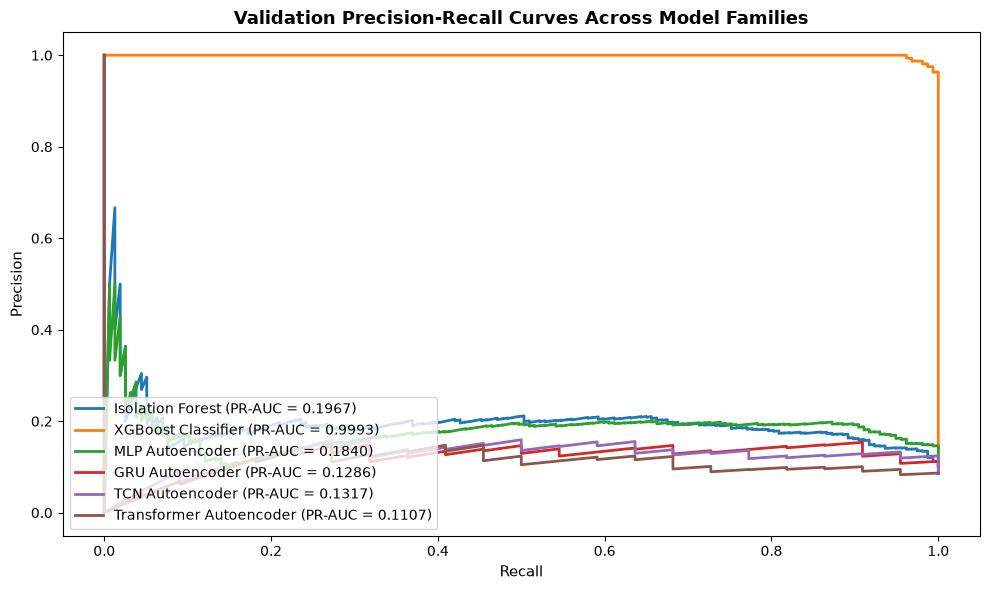

In [18]:
plt.figure(figsize=(10, 6))

for name, y_true, scores in [
    ('Isolation Forest', y_val, val_scores_if),
    ('XGBoost Classifier', y_val, val_scores_xgb),
    ('MLP Autoencoder', y_val, val_err_mlp),
    ('GRU Autoencoder', y_seq_val, val_err_gru),
    ('TCN Autoencoder', y_seq_val, val_err_tcn),
    ('Transformer Autoencoder', y_seq_val, val_err_tf),
]:
    p, r, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)
    plt.plot(r, p, lw=2, label=f"{name} (PR-AUC = {pr_auc:.4f})")

plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Validation Precision-Recall Curves Across Model Families', fontsize=13, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## Threshold Locking & Out-of-Time Test Evaluation (2025)

In [19]:
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_val, (val_scores_xgb >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Optimal Locked Anomaly Threshold: {best_thresh:.4f} (Validation F1 = {max(f1_scores):.4f})')

Optimal Locked Anomaly Threshold: 0.3900 (Validation F1 = 0.9842)


In [20]:
test_scores_xgb = xgb_model.predict_proba(X_test)
test_preds = (test_scores_xgb >= best_thresh).astype(int)

print('=== TEST SET EVALUATION (2025 OUT-OF-TIME) ===')
print(f'Precision: {precision_score(y_test, test_preds)*100:.2f}%')
print(f'Recall:    {recall_score(y_test, test_preds)*100:.2f}%')
print(f'F1 Score:  {f1_score(y_test, test_preds):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, test_scores_xgb):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, test_scores_xgb):.4f}')

=== TEST SET EVALUATION (2025 OUT-OF-TIME) ===
Precision: 97.84%
Recall:    100.00%
F1 Score:  0.9891
PR-AUC:    1.0000
ROC-AUC:   1.0000


## Breakdown by Semantic Anomaly Category

In [21]:
test_df_eval = test_df.copy()
test_df_eval['pred_flag'] = test_preds
type_eval = []
for a_type in ['NORMAL', 'VOLUME_SURGE', 'UNEXPECTED_COLLAPSE']:
    sub = test_df_eval[test_df_eval['anomaly_type'] == a_type]
    if a_type == 'NORMAL':
        acc = (sub['pred_flag'] == 0).mean() * 100
        fpr = (sub['pred_flag'] == 1).mean() * 100
        type_eval.append({'Category': a_type, 'Count': len(sub), 'Accuracy (%)': f'{acc:.2f}%', 'Error/FPR (%)': f'{fpr:.2f}%'})
    else:
        rec = (sub['pred_flag'] == 1).mean() * 100
        type_eval.append({'Category': a_type, 'Count': len(sub), 'Recall (%)': f'{rec:.2f}%', 'Miss Rate (%)': f'{100-rec:.2f}%'})

pd.DataFrame(type_eval)

,Category,Count,Accuracy (%),Error/FPR (%),Recall (%),Miss Rate (%)
0,NORMAL,2755,99.75%,0.25%,NaN,NaN
1,VOLUME_SURGE,271,NaN,NaN,100.00%,0.00%
2,UNEXPECTED_COLLAPSE,46,NaN,NaN,100.00%,0.00%


## Live Production Inference Service Check

In [22]:
from src.trade_anomaly.inference import TradeAnomalyInferenceService

service = TradeAnomalyInferenceService()
sample_pred = service.predict(
    trade_flow='Export',
    hs6=100630,
    partner_country='ARE',
    trade_value_usd=150000000.0,
    quantity=120000000.0,
    quantity_unit='kg',
    period='2025-12'
)
print(json.dumps(sample_pred, indent=2))

{
  "status": "OK",
  "trade_context": {
    "trade_flow": "Export",
    "hs6": 100630,
    "product_description": "Semi-milled or wholly milled rice, whether or not polished or glazed (Basmati)",
    "partner_country": "ARE",
    "period": "202512",
    "trade_value_usd": 150000000.0,
    "quantity": 120000000.0,
    "unit_value_usd_per_kg": 1.25
  },
  "risk": {
    "is_anomaly": false,
    "anomaly_score": 0.15,
    "risk_level": "LOW",
    "threshold": 0.5
  },
  "classification": {
    "anomaly_type": "NORMAL",
    "confidence": 0.85
  },
  "signals": [
    {
      "signal": "TRADE_VALUE_SPIKE",
      "severity": "HIGH",
      "message": "Trade value increased +691.0% compared with the previous month."
    },
    {
      "signal": "ROLLING_BASELINE_SURGE",
      "severity": "HIGH",
      "message": "Current trade value is 9.28x higher than the recent 3-month corridor baseline."
    },
    {
      "signal": "PARTNER_SHARE_SHIFT",
      "severity": "MEDIUM",
      "message": "Partne